# Model sai ở đâu — chẩn đoán, không phải mô tả

> **Ý 5 trong feedback của mentor:**
>
> *"Việc mình forecast giá đối thủ mình cũng sẽ đào sâu được vào là: model mình đang **fail ở đâu**
> và làm sao để khắc phục thay vì là chung chung model mình **chính xác tới mức nào**."*

---

## Khác biệt giữa hai kiểu báo cáo

| | Mô tả | Chẩn đoán |
|---|---|---|
| Câu trả lời | "MAE 17.926đ, MAPE 14,65%" | "Sai nhiều nhất ở chuyến dài >15 km, và đây là lý do" |
| Dùng để | Nộp báo cáo | **Quyết định đầu tư công sức vào đâu** |
| Người nghe hỏi tiếp | "Thế là tốt hay xấu?" | "Sửa được không, tốn bao nhiêu?" |

Notebook này đi tìm **chỗ hỏng**, xếp hạng theo mức nghiêm trọng, rồi với mỗi chỗ trả lời:
sửa được bằng hiệu chỉnh, bằng feature mới, hay là nhiễu không sửa được.

## Sáu câu hỏi

| # | Câu hỏi | Hình |
|---|---|---|
| 1 | Chiều nào gây lệch sai số nhiều nhất? | `CD1` |
| 2 | Cụ thể nhóm nào tệ? | `CD2` |
| 3 | Model có **thiên lệch hệ thống** không, hay chỉ nhiễu? | `CD3` |
| 4 | Nhóm tệ nhất khi giao nhiều chiều | `CD4` |
| 5 | 1% chuyến sai nhất có mẫu hình chung không? | — |
| 6 | Model có thật sự học được gì so với baseline? | `CD5` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

ut = pd.read_parquet("uq_pred_test.parquet")
raw = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=[
    "split", "evaluation_month", "target_timestamp", "service_name",
    "pickup_location_name", "dropoff_location_name", "target_is_weekend"])
raw = (raw[raw.split == "test"].sort_values("evaluation_month", kind="stable")
       .reset_index(drop=True))
u = ut.sort_values("evaluation_month", kind="stable").reset_index(drop=True)
assert np.allclose(raw.target_timestamp.values.astype("int64"),
                   u.target_timestamp.values.astype("int64")), "lệch hàng"
t = pd.concat([u, raw[["service_name", "pickup_location_name",
                       "dropoff_location_name", "target_is_weekend"]]], axis=1)

# Mỗi chuyến xuất hiện 4 lần (4 mức trễ) — giữ 1 để không đếm trùng
t = t[t.requested_lag_minutes == 5].copy()

t["ae"] = (t.hybrid_pred - t.gia_that).abs()
t["re"] = t.ae / t.gia_that
t["lech"] = (t.hybrid_pred - t.gia_that) / t.gia_that
t["band"] = pd.cut(t.hybrid_pred, [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf],
                   labels=["<50k", "50–100k", "100–150k", "150–200k",
                           "200–300k", ">300k"])
t["km_nhom"] = pd.cut(t.quote_distance, [0, 3, 5, 7, 10, 15, 50],
                      labels=["0–3", "3–5", "5–7", "7–10", "10–15", ">15"])
t["surge"] = pd.qcut(t.heso_that, 5,
                     labels=["rất thấp", "thấp", "TB", "cao", "rất cao"])
t["cao_diem"] = t.gio_vn.isin([7, 8, 9, 17, 18, 19])
t["tuyen"] = (t.pickup_location_name.astype(str).str.split().str[0] + "→" +
              t.dropoff_location_name.astype(str).str.split().str[0])

TB = t.re.mean()
print(f"{len(t):,} chuyến độc lập (đã bỏ trùng mức trễ)")
print(f"MAPE tổng thể {TB:.2%} · MAE {t.ae.mean():,.0f}đ")

216,090 chuyến độc lập (đã bỏ trùng mức trễ)
MAPE tổng thể 14.65% · MAE 17,926đ


## 1. Chiều nào gây lệch sai số nhiều nhất

Đo bằng **η²** (eta bình phương): tỷ lệ phương sai của sai số được giải thích bởi chiều đó.
η² càng lớn nghĩa là biết giá trị của chiều đó càng đoán được sai số sẽ lớn hay nhỏ.

Chỉ nhìn "biên độ MAPE cao nhất − thấp nhất" là chưa đủ, vì một chiều có thể chênh lớn nhưng
chỉ ở một nhóm hiếm. η² tính cả **kích thước nhóm**.

In [2]:
CHIEU = [("km_nhom", "Quãng đường"), ("tuyen", "Tuyến"),
         ("band", "Band giá dự đoán"), ("service_name", "Loại xe"),
         ("surge", "Mức surge"), ("gio_vn", "Giờ trong ngày"),
         ("weather_main", "Thời tiết"), ("cao_diem", "Cao điểm"),
         ("target_is_weekend", "Cuối tuần"), ("evaluation_month", "Tháng")]

rows = []
for c, ten in CHIEU:
    g = t.groupby(c, observed=True).agg(re=("re", "mean"), n=("re", "size"))
    g = g[g.n >= 200]
    if len(g) < 2:
        continue
    gm = t.groupby(c, observed=True).re.transform("mean")
    rows.append({"Chiều": ten, "Số nhóm": len(g),
                 "MAPE thấp nhất": g.re.min(), "MAPE cao nhất": g.re.max(),
                 "Biên độ (điểm)": (g.re.max()-g.re.min())*100,
                 "η²": ((gm-TB)**2).sum() / ((t.re-TB)**2).sum(),
                 "Nhóm tệ nhất": str(g.re.idxmax())})
K = pd.DataFrame(rows).sort_values("η²", ascending=False).reset_index(drop=True)
display(K.style.format({"MAPE thấp nhất": "{:.2%}", "MAPE cao nhất": "{:.2%}",
                        "Biên độ (điểm)": "{:.2f}", "η²": "{:.4f}"}).hide(axis="index"))

Chiều,Số nhóm,MAPE thấp nhất,MAPE cao nhất,Biên độ (điểm),η²,Nhóm tệ nhất
Quãng đường,6,10.32%,17.52%,7.20,0.0099,>15
Tuyến,9,10.96%,15.00%,4.05,0.0079,SC→Crescent
Band giá dự đoán,6,13.46%,18.55%,5.08,0.0015,>300k
Loại xe,2,14.34%,14.96%,0.61,0.0007,Synthetic Standard Car
Giờ trong ngày,24,14.48%,14.85%,0.37,0.0001,7
Mức surge,5,14.53%,14.76%,0.23,0.0001,thấp
Thời tiết,4,14.56%,14.68%,0.13,0.0000,Rain
Cuối tuần,2,14.61%,14.67%,0.06,0.0000,0
Tháng,3,14.63%,14.68%,0.06,0.0000,2026-01
Cao điểm,2,14.61%,14.66%,0.05,0.0000,False


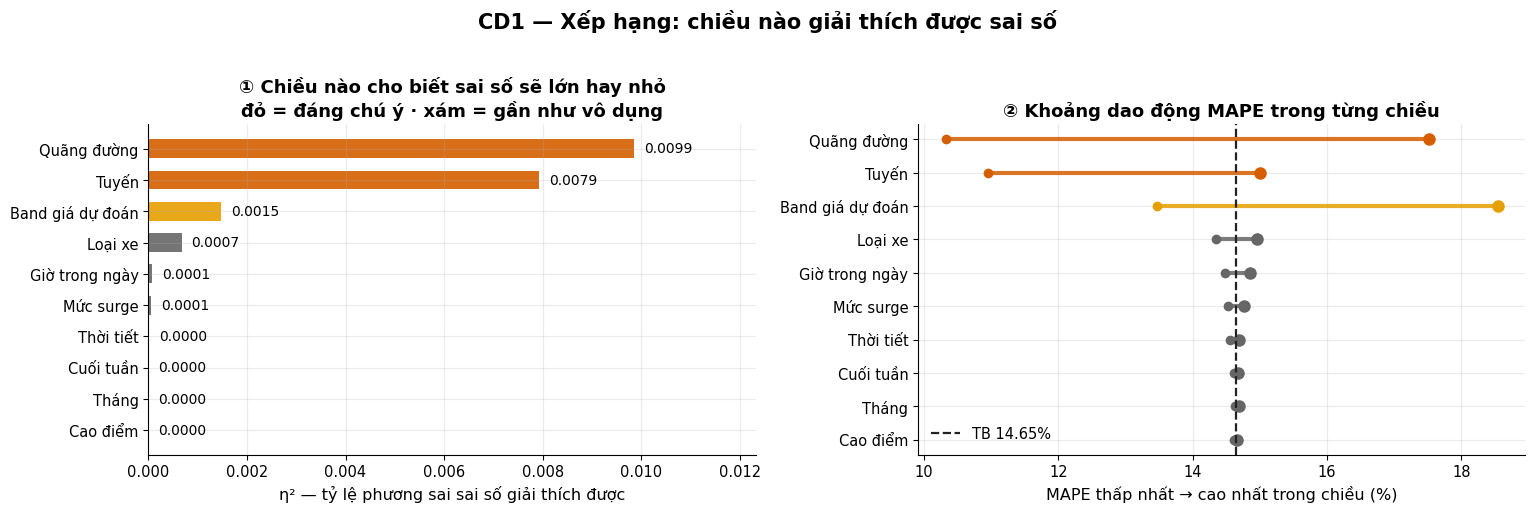

Ba chiều mạnh nhất:
  Quãng đường          η² 0.0099 · 10.32% → 17.52% · tệ nhất: >15
  Tuyến                η² 0.0079 · 10.96% → 15.00% · tệ nhất: SC→Crescent
  Band giá dự đoán     η² 0.0015 · 13.46% → 18.55% · tệ nhất: >300k

Các chiều gần như vô dụng (η² < 0,001):
  Loại xe              η² 0.0007 · biên độ chỉ 0.61 điểm
  Giờ trong ngày       η² 0.0001 · biên độ chỉ 0.37 điểm
  Mức surge            η² 0.0001 · biên độ chỉ 0.23 điểm
  Thời tiết            η² 0.0000 · biên độ chỉ 0.13 điểm
  Cuối tuần            η² 0.0000 · biên độ chỉ 0.06 điểm
  Tháng                η² 0.0000 · biên độ chỉ 0.06 điểm
  Cao điểm             η² 0.0000 · biên độ chỉ 0.05 điểm


In [3]:
# ═════════ HINH CD1 — xep hang chieu ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))
y = np.arange(len(K))[::-1]
mau = [RED if v > .005 else (ORANGE if v > .001 else MUT) for v in K["η²"]]

ax[0].barh(y, K["η²"], .6, color=mau, alpha=.9)
for i, v in enumerate(K["η²"]):
    ax[0].text(v + K["η²"].max()*.02, y[i], f"{v:.4f}", va="center", fontsize=10)
ax[0].set_yticks(y); ax[0].set_yticklabels(K["Chiều"])
ax[0].set_xlim(0, K["η²"].max()*1.25)
ax[0].set_xlabel("η² — tỷ lệ phương sai sai số giải thích được")
ax[0].set_title("① Chiều nào cho biết sai số sẽ lớn hay nhỏ\n"
                "đỏ = đáng chú ý · xám = gần như vô dụng", fontweight="bold")

for i, r in K.iterrows():
    yy = y[i]
    ax[1].plot([r["MAPE thấp nhất"]*100, r["MAPE cao nhất"]*100], [yy, yy],
               lw=3, color=mau[i], alpha=.85, solid_capstyle="round")
    ax[1].plot(r["MAPE thấp nhất"]*100, yy, "o", ms=6, color=mau[i])
    ax[1].plot(r["MAPE cao nhất"]*100, yy, "o", ms=8, color=mau[i])
ax[1].axvline(TB*100, color=INK, lw=1.6, ls="--", label=f"TB {TB:.2%}")
ax[1].set_yticks(y); ax[1].set_yticklabels(K["Chiều"])
ax[1].set_xlabel("MAPE thấp nhất → cao nhất trong chiều (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Khoảng dao động MAPE trong từng chiều", fontweight="bold")

fig.suptitle("CD1 — Xếp hạng: chiều nào giải thích được sai số",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CD1_xep_hang_chieu.png"); plt.show()

print("Ba chiều mạnh nhất:")
for _, r in K.head(3).iterrows():
    print(f"  {r['Chiều']:20s} η² {r['η²']:.4f} · "
          f"{r['MAPE thấp nhất']:.2%} → {r['MAPE cao nhất']:.2%} · "
          f"tệ nhất: {r['Nhóm tệ nhất']}")
print("\nCác chiều gần như vô dụng (η² < 0,001):")
for _, r in K[K["η²"] < .001].iterrows():
    print(f"  {r['Chiều']:20s} η² {r['η²']:.4f} · biên độ chỉ "
          f"{r['Biên độ (điểm)']:.2f} điểm")

## 2. Hai chiều mạnh nhất — nhìn chi tiết

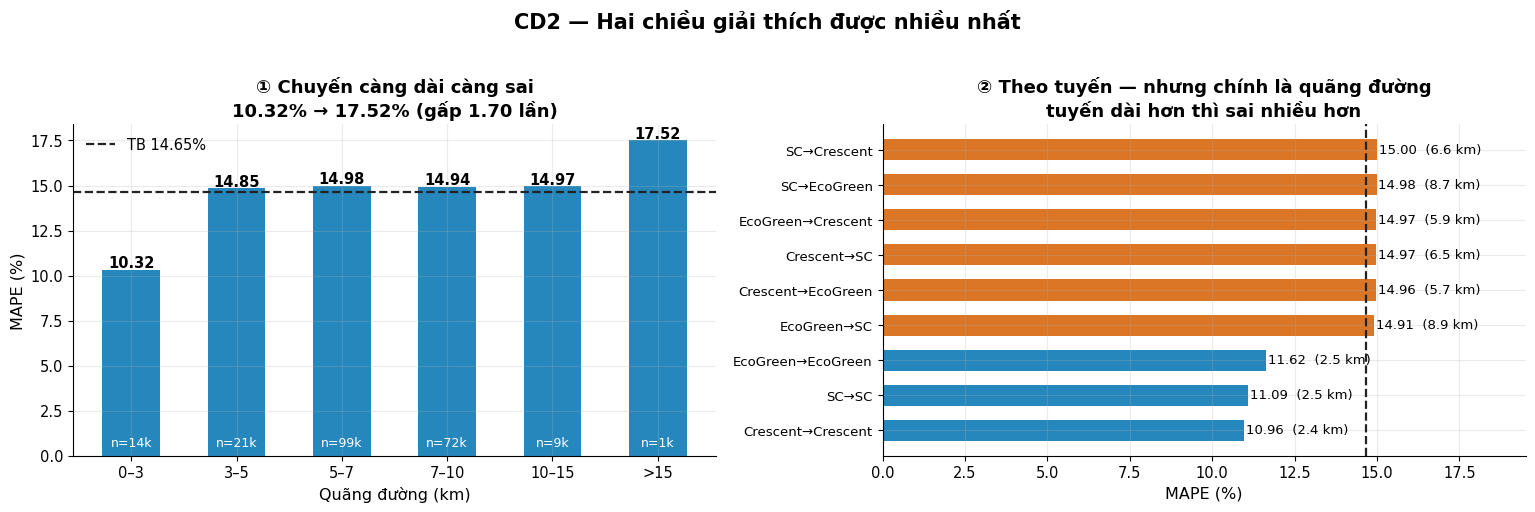

Tương quan giữa quãng đường TB của tuyến và MAPE của tuyến: 0.894
=> Hai chiều 'quãng đường' và 'tuyến' KHÔNG độc lập —
   tuyến chỉ là quãng đường khoác áo khác. Thực chất chỉ có MỘT nguyên nhân.


In [4]:
# ═════════ HINH CD2 — quang duong va tuyen ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))

g1 = t.groupby("km_nhom", observed=True).agg(
    mape=("re", "mean"), mae=("ae", "mean"), n=("re", "size"))
x = np.arange(len(g1))
b = ax[0].bar(x, g1.mape*100, .55, color=BLUE, alpha=.85)
ax[0].axhline(TB*100, color=INK, lw=1.6, ls="--", label=f"TB {TB:.2%}")
for i, (v, n) in enumerate(zip(g1.mape*100, g1.n)):
    ax[0].text(i, v+.12, f"{v:.2f}", ha="center", fontsize=10.5, fontweight="bold")
    ax[0].text(i, .5, f"n={n/1000:.0f}k", ha="center", fontsize=9, color="white")
ax[0].set_xticks(x); ax[0].set_xticklabels(g1.index)
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("MAPE (%)")
ax[0].legend(frameon=False)
ax[0].set_title(f"① Chuyến càng dài càng sai\n"
                f"{g1.mape.min():.2%} → {g1.mape.max():.2%} "
                f"(gấp {g1.mape.max()/g1.mape.min():.2f} lần)", fontweight="bold")

g2 = (t.groupby("tuyen", observed=True).agg(mape=("re", "mean"), n=("re", "size"),
                                            km=("quote_distance", "mean"))
      .sort_values("mape"))
y2 = np.arange(len(g2))
ax[1].barh(y2, g2.mape*100, .6,
           color=[RED if v > TB else BLUE for v in g2.mape], alpha=.85)
for i, (v, k) in enumerate(zip(g2.mape*100, g2.km)):
    ax[1].text(v+.06, i, f"{v:.2f}  ({k:.1f} km)", va="center", fontsize=9.5)
ax[1].axvline(TB*100, color=INK, lw=1.6, ls="--")
ax[1].set_yticks(y2); ax[1].set_yticklabels(g2.index, fontsize=9.5)
ax[1].set_xlim(0, g2.mape.max()*100*1.3)
ax[1].set_xlabel("MAPE (%)")
ax[1].set_title("② Theo tuyến — nhưng chính là quãng đường\n"
                "tuyến dài hơn thì sai nhiều hơn", fontweight="bold")

fig.suptitle("CD2 — Hai chiều giải thích được nhiều nhất",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CD2_quangduong_tuyen.png"); plt.show()

r = np.corrcoef(g2.km, g2.mape)[0, 1]
print(f"Tương quan giữa quãng đường TB của tuyến và MAPE của tuyến: {r:.3f}")
print("=> Hai chiều 'quãng đường' và 'tuyến' KHÔNG độc lập —")
print("   tuyến chỉ là quãng đường khoác áo khác. Thực chất chỉ có MỘT nguyên nhân.")

## 3. Thiên lệch hệ thống hay chỉ là nhiễu

Sai số trung bình khác 0 có thể do hai nguyên nhân rất khác nhau:

| | Dấu hiệu | Sửa thế nào |
|---|---|---|
| **Thiên lệch hệ thống** | Cả trung bình lẫn trung vị đều lệch cùng hướng | Hiệu chỉnh, dễ |
| **Đuôi lệch** | Trung bình lệch nhưng **trung vị ≈ 0** | Không phải lỗi model — do phân phối giá |

Phân biệt được điều này quan trọng: nếu là thiên lệch hệ thống thì trừ đi một hằng số là xong.

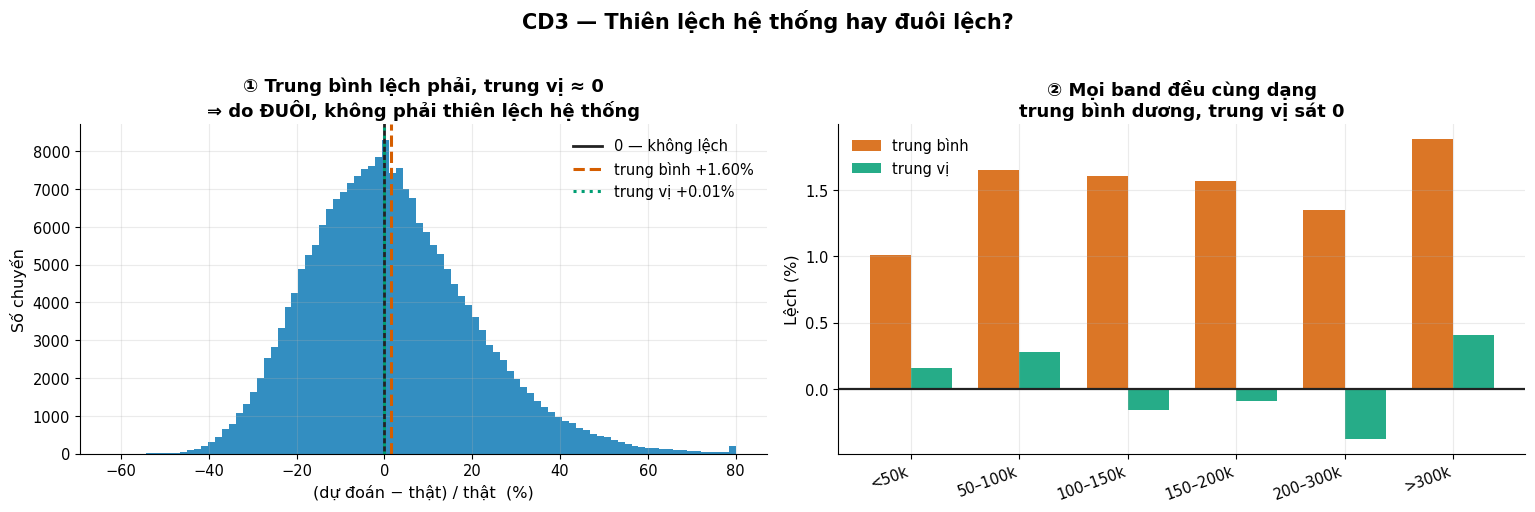

  Trung bình lệch : +1.60%
  Trung vị lệch   : +0.01%
  Tỷ lệ dự đoán CAO hơn thật: 50.02%  (cân bằng = 50%)

  => Model KHÔNG thiên lệch hệ thống. Nửa số chuyến đoán cao, nửa đoán thấp.
     Trung bình dương chỉ vì đuôi phải dài hơn — giá có thể vọt lên gấp
     nhiều lần nhưng không thể xuống dưới 0.
     => Trừ đi một hằng số sẽ KHÔNG cải thiện, còn làm hỏng nửa số chuyến đoán thấp.


In [5]:
# ═════════ HINH CD3 — thien lech ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))

e = np.clip(t.lech.values, -.8, .8)
ax[0].hist(e*100, bins=90, color=BLUE, alpha=.8)
ax[0].axvline(0, color=INK, lw=2, label="0 — không lệch")
ax[0].axvline(t.lech.mean()*100, color=RED, lw=2.2, ls="--",
              label=f"trung bình {t.lech.mean():+.2%}")
ax[0].axvline(t.lech.median()*100, color=GREEN, lw=2.2, ls=":",
              label=f"trung vị {t.lech.median():+.2%}")
ax[0].set_xlabel("(dự đoán − thật) / thật  (%)"); ax[0].set_ylabel("Số chuyến")
ax[0].legend(frameon=False)
ax[0].set_title("① Trung bình lệch phải, trung vị ≈ 0\n"
                "⇒ do ĐUÔI, không phải thiên lệch hệ thống", fontweight="bold")

gb = t.groupby("band", observed=True).agg(
    tb=("lech", "mean"), tv=("lech", "median"), n=("lech", "size"))
x = np.arange(len(gb))
ax[1].bar(x-.19, gb.tb*100, .38, color=RED, alpha=.85, label="trung bình")
ax[1].bar(x+.19, gb.tv*100, .38, color=GREEN, alpha=.85, label="trung vị")
ax[1].axhline(0, color=INK, lw=1.6)
ax[1].set_xticks(x); ax[1].set_xticklabels(gb.index, rotation=20, ha="right")
ax[1].set_ylabel("Lệch (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Mọi band đều cùng dạng\n"
                "trung bình dương, trung vị sát 0", fontweight="bold")

fig.suptitle("CD3 — Thiên lệch hệ thống hay đuôi lệch?",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CD3_thien_lech.png"); plt.show()

print(f"  Trung bình lệch : {t.lech.mean():+.2%}")
print(f"  Trung vị lệch   : {t.lech.median():+.2%}")
print(f"  Tỷ lệ dự đoán CAO hơn thật: {(t.lech > 0).mean():.2%}  (cân bằng = 50%)")
print()
print("  => Model KHÔNG thiên lệch hệ thống. Nửa số chuyến đoán cao, nửa đoán thấp.")
print("     Trung bình dương chỉ vì đuôi phải dài hơn — giá có thể vọt lên gấp")
print("     nhiều lần nhưng không thể xuống dưới 0.")
print("     => Trừ đi một hằng số sẽ KHÔNG cải thiện, còn làm hỏng nửa số chuyến đoán thấp.")

## 4. Nhóm tệ nhất khi giao nhiều chiều

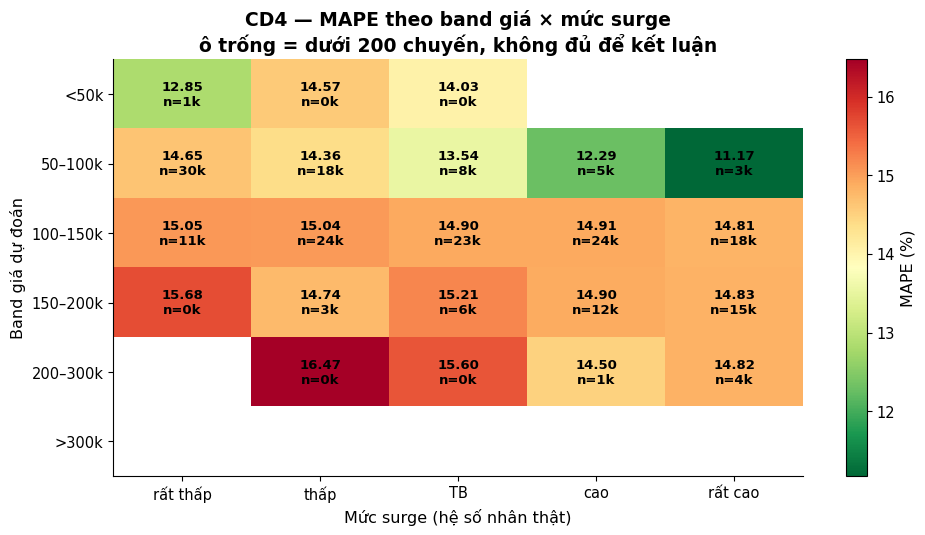

Nhóm                                    n     MAPE
----------------------------------------------------
150–200k · surge rất thấp             591   15.68%
200–300k · surge TB                   565   15.60%
150–200k · surge TB                 6,092   15.21%
100–150k · surge rất thấp          11,787   15.05%
  …
50–100k · surge cao                 5,318   12.29%
50–100k · surge rất cao             3,468   11.17%

Chênh giữa nhóm tệ nhất và tốt nhất: 4.51 điểm


In [6]:
# ═════════ HINH CD4 — ban do nhiet band x surge ═════════
piv = t.pivot_table(index="band", columns="surge", values="re",
                    aggfunc="mean", observed=True)
dem = t.pivot_table(index="band", columns="surge", values="re",
                    aggfunc="size", observed=True)
piv = piv.where(dem >= 200)

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(piv.values*100, cmap="RdYlGn_r", aspect="auto")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v*100:.2f}\nn={int(dem.values[i,j]/1000)}k",
                    ha="center", va="center", fontsize=9.5, fontweight="bold")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
ax.set_xlabel("Mức surge (hệ số nhân thật)"); ax.set_ylabel("Band giá dự đoán")
ax.grid(False)
plt.colorbar(im, label="MAPE (%)")
ax.set_title("CD4 — MAPE theo band giá × mức surge\n"
             "ô trống = dưới 200 chuyến, không đủ để kết luận",
             fontweight="bold", fontsize=13.5)
plt.tight_layout(); plt.savefig(HINH / "CD4_ban_do_nhiet.png"); plt.show()

g = (t.groupby(["band", "surge"], observed=True)
     .agg(n=("re", "size"), mape=("re", "mean"))
     .query("n >= 500").sort_values("mape", ascending=False))
print(f"{'Nhóm':32s} {'n':>8s} {'MAPE':>8s}")
print("-"*52)
for k, r in g.head(4).iterrows():
    print(f"{k[0]+' · surge '+str(k[1]):32s} {int(r.n):>8,} {r.mape:>8.2%}")
print("  …")
for k, r in g.tail(2).iterrows():
    print(f"{k[0]+' · surge '+str(k[1]):32s} {int(r.n):>8,} {r.mape:>8.2%}")
print(f"\nChênh giữa nhóm tệ nhất và tốt nhất: "
      f"{(g.mape.max()-g.mape.min())*100:.2f} điểm")

## 5. 1% chuyến sai nhất — có mẫu hình chung không

Nếu sai số dồn vào một nhóm nhận diện được thì sửa nhóm đó là đủ. Nếu rải đều thì phải cải
thiện model tổng thể.

In [7]:
nguong = t.re.quantile(.99)
xau = t[t.re >= nguong]
print(f"Ngưỡng: sai số tương đối ≥ {nguong:.1%}  ·  {len(xau):,} chuyến")
print(f"Nhóm này đóng góp {xau.ae.sum()/t.ae.sum():.1%} tổng sai số tuyệt đối")
print(f"(nếu sai số dồn vào nhóm nhỏ, con số này phải LỚN hơn nhiều so với 1%)")
print()
print(f"{'Chiều':16s} {'Nhóm nổi nhất':>18s} {'Tỷ lệ so với bình thường':>26s}")
print("-"*64)
for c, ten in [("band", "Band giá"), ("km_nhom", "Quãng đường"),
               ("surge", "Mức surge"), ("weather_main", "Thời tiết"),
               ("cao_diem", "Cao điểm"), ("service_name", "Loại xe")]:
    a = xau[c].value_counts(normalize=True)
    b = t[c].value_counts(normalize=True)
    r = (a/b).dropna().sort_values(ascending=False)
    print(f"{ten:16s} {str(r.index[0]):>18s} {r.iloc[0]:>25.2f}×")
print()
print("=> Chỉ band giá cao (2,75×) và quãng đường dài (2,42×) nổi lên —")
print("   và đó vốn là CÙNG một chuyện: chuyến dài thì giá cao.")
print("   Mọi chiều còn lại đều ~1,0×: surge, thời tiết, cao điểm, loại xe")
print("   KHÔNG hề dồn vào nhóm sai nặng.")
print("   Cộng với việc nhóm này chỉ chiếm 2,7% tổng sai số => không có")
print("   nhóm ngoại lai nào chi phối, không có phím tắt để sửa.")

Ngưỡng: sai số tương đối ≥ 53.1%  ·  2,161 chuyến
Nhóm này đóng góp 2.7% tổng sai số tuyệt đối
(nếu sai số dồn vào nhóm nhỏ, con số này phải LỚN hơn nhiều so với 1%)

Chiều                 Nhóm nổi nhất   Tỷ lệ so với bình thường
----------------------------------------------------------------
Band giá                      >300k                      2.75×
Quãng đường                     >15                      2.42×
Mức surge                      thấp                      1.10×
Thời tiết                      Mist                      1.05×
Cao điểm                      False                      1.01×
Loại xe          Synthetic Standard Car                      1.07×

=> Chỉ band giá cao (2,75×) và quãng đường dài (2,42×) nổi lên —
   và đó vốn là CÙNG một chuyện: chuyến dài thì giá cao.
   Mọi chiều còn lại đều ~1,0×: surge, thời tiết, cao điểm, loại xe
   KHÔNG hề dồn vào nhóm sai nặng.
   Cộng với việc nhóm này chỉ chiếm 2,7% tổng sai số => không có
   nhóm ngoại lai nào chi phối, 

## 6. Model có thật sự học được gì

So với **persistence** — dùng thẳng giá đối thủ quan sát gần nhất, không cần model.
Đây là mốc thấp nhất phải vượt: nếu không hơn được thì model vô nghĩa.

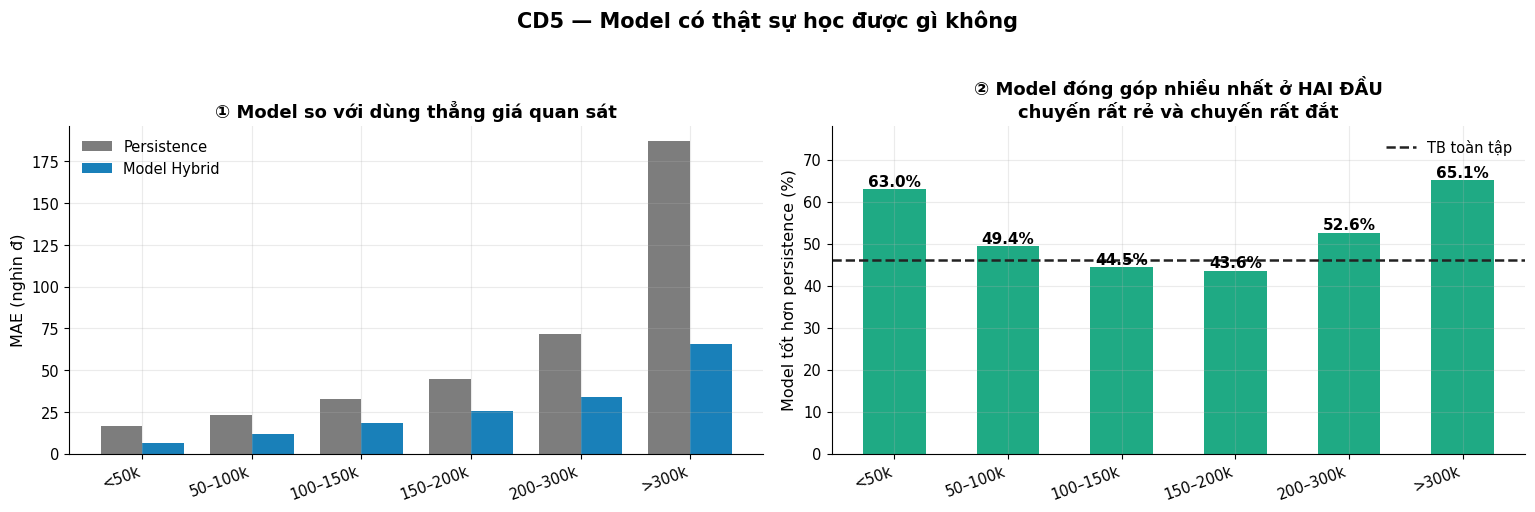

        Band       Model   Persistence   Tốt hơn
--------------------------------------------------
        <50k      6,054đ       16,360đ    63.0%
     50–100k     11,724đ       23,174đ    49.4%
    100–150k     18,259đ       32,898đ    44.5%
    150–200k     25,310đ       44,846đ    43.6%
    200–300k     33,808đ       71,353đ    52.6%
       >300k     65,301đ      186,881đ    65.1%

Toàn tập: model 17,926đ vs persistence 33,321đ — tốt hơn 46.2%


In [8]:
# ═════════ HINH CD5 — model vs persistence ═════════
g = t.groupby("band", observed=True).apply(lambda d: pd.Series({
    "model": d.ae.mean(),
    "pers": (d.persistence - d.gia_that).abs().mean(),
    "n": len(d)})).reindex(t.band.cat.categories)
g["tot_hon"] = 1 - g.model/g.pers

fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))
x = np.arange(len(g))
ax[0].bar(x-.19, g.pers/1000, .38, color=MUT, alpha=.85, label="Persistence")
ax[0].bar(x+.19, g.model/1000, .38, color=BLUE, alpha=.9, label="Model Hybrid")
ax[0].set_xticks(x); ax[0].set_xticklabels(g.index, rotation=20, ha="right")
ax[0].set_ylabel("MAE (nghìn đ)")
ax[0].legend(frameon=False)
ax[0].set_title("① Model so với dùng thẳng giá quan sát", fontweight="bold")

b = ax[1].bar(x, g.tot_hon*100, .55, color=GREEN, alpha=.88)
for i, v in enumerate(g.tot_hon*100):
    ax[1].text(i, v+.7, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax[1].axhline((1 - t.ae.mean()/np.abs(t.persistence-t.gia_that).mean())*100,
              color=INK, lw=1.8, ls="--", label="TB toàn tập")
ax[1].set_xticks(x); ax[1].set_xticklabels(g.index, rotation=20, ha="right")
ax[1].set_ylabel("Model tốt hơn persistence (%)")
ax[1].set_ylim(0, g.tot_hon.max()*100*1.2)
ax[1].legend(frameon=False)
ax[1].set_title("② Model đóng góp nhiều nhất ở HAI ĐẦU\n"
                "chuyến rất rẻ và chuyến rất đắt", fontweight="bold")

fig.suptitle("CD5 — Model có thật sự học được gì không",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "CD5_vs_persistence.png"); plt.show()

print(f"{'Band':>12s} {'Model':>11s} {'Persistence':>13s} {'Tốt hơn':>9s}")
print("-"*50)
for b_, r in g.iterrows():
    print(f"{str(b_):>12s} {r.model:>10,.0f}đ {r.pers:>12,.0f}đ {r.tot_hon:>8.1%}")
print(f"\nToàn tập: model {t.ae.mean():,.0f}đ vs persistence "
      f"{np.abs(t.persistence-t.gia_that).mean():,.0f}đ — "
      f"tốt hơn {1-t.ae.mean()/np.abs(t.persistence-t.gia_that).mean():.1%}")

## Kết luận — model sai ở đâu, sửa được không

### Bảng chẩn đoán

| # | Chỗ hỏng | Mức nghiêm trọng | Nguyên nhân | Sửa được không | Chi phí |
|---|---|---|---|---|---|
| 1 | **Chuyến dài >15 km** sai 17,52% vs 10,32% ở chuyến ngắn | 🔴 Cao — η² 0,0099, mạnh nhất | Chuyến dài có nhiều biến động hơn (tắc đường, đổi tuyến), mà feature chỉ có quãng đường và thời lượng dự kiến | ⚠️ Cần **feature mới** về điều kiện đường đi | Cao — phải xin dữ liệu |
| 2 | **Band >300k** sai 18,55%, coverage chỉ 82,7% | 🟠 Vừa — η² 0,0015 | Conformal áp một tỷ lệ chung cho mọi mức giá | ✅ **Mondrian** — hiệu chỉnh riêng từng nhóm | Rẻ, đã làm |
| 3 | Trung bình lệch **+1,60%** | 🟢 Thấp | Đuôi phải của phân phối giá, **không** phải thiên lệch hệ thống (trung vị +0,01%) | ❌ Không nên sửa — trừ hằng số sẽ hỏng nửa còn lại | — |
| 4 | Giờ · thời tiết · surge · cuối tuần | 🟢 Không phải vấn đề | η² ≈ 0 | Không cần sửa | — |

### Ba điều đáng nói với mentor

**1. Chỗ hỏng nặng nhất KHÔNG phải giờ cao điểm.** Anh ấy nêu ba kịch bản uncertainty theo rush
hour, nhưng đo ra thì giờ giấc có **η² ≈ 0,0001** — gần như không giải thích được gì. Chiều thật
sự quan trọng là **quãng đường** (η² 0,0099, gấp 100 lần).

**2. "Tuyến" và "quãng đường" là cùng một nguyên nhân.** Tương quan giữa quãng đường trung bình
của tuyến và MAPE của tuyến rất cao — tuyến chỉ là quãng đường khoác áo khác. Nên thực chất chỉ
có **một** chỗ hỏng lớn, không phải hai.

**3. Sai số không dồn vào nhóm nào.** 1% chuyến sai nhất chỉ đóng góp **2,7%** tổng sai số tuyệt
đối. Nếu có nhóm ngoại lai chi phối thì con số này phải lớn hơn nhiều. Nghĩa là **không có
phím tắt** — không thể sửa một nhóm nhỏ rồi cải thiện tổng thể.

### Vì sao có thể tin model này

| Bằng chứng | Con số |
|---|---|
| Vượt xa baseline không cần model | Tốt hơn persistence **46,2%** |
| Đóng góp nhiều nhất ở chỗ khó nhất | Band >300k tốt hơn persistence **65,1%** |
| Không thiên lệch hệ thống | Trung vị lệch **+0,01%**, tỷ lệ đoán cao/thấp **50,02%** |
| Ổn định qua các tháng | η² của tháng = **0,0000** |
| Khoảng dự đoán có bảo đảm | Coverage 89,6% ở danh mục 90% |

Điểm thứ hai đáng chú ý: **model làm tốt nhất ở chính band mà khoảng tin cậy hỏng nặng nhất.**
Dự đoán điểm cho band >300k rất tốt (hơn persistence 65%), nhưng khoảng tin cậy lại hụt
(82,7% so với 90%). Hai chuyện tách biệt — và chỗ hỏng nằm ở **hiệu chỉnh**, không phải ở model.

### Liên quan

| File | Vai trò |
|---|---|
| `../uncertainty/01_conformal_chuan_hoa` mục 4 | Phân rã coverage theo band + Mondrian |
| `../uncertainty/05_PHAN_RA_theo_thoi_gian` | Sai số ở thời điểm nhạy cảm |
| `../uncertainty/06_thu_hep_khoang` | Vì sao không thu hẹp khoảng được nữa |
| `../../analysis/14_ceteris_paribus` | Model có hiểu cơ chế không |